In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# =============================================================================
# 1. Define POS Tags and Vocabulary (Same as previous demo)
# =============================================================================

POS_TAGS = ['DET', 'NOUN', 'VERB', 'ADJ', 'ADV', 'PREP', 'PRON', 'CONJ']

VOCABULARY = {
    'the': ['DET'], 'a': ['DET'], 'an': ['DET'], 'this': ['DET'], 'that': ['DET'],
    'dog': ['NOUN'], 'cat': ['NOUN'], 'book': ['NOUN'], 'house': ['NOUN'], 
    'car': ['NOUN'], 'man': ['NOUN'], 'woman': ['NOUN'], 'child': ['NOUN'],
    'time': ['NOUN'], 'way': ['NOUN'],
    'runs': ['VERB'], 'eats': ['VERB'], 'reads': ['VERB'], 'is': ['VERB'],
    'was': ['VERB'], 'has': ['VERB'], 'goes': ['VERB'], 'sees': ['VERB'],
    'likes': ['VERB'], 'wants': ['VERB'],
    'big': ['ADJ'], 'small': ['ADJ'], 'red': ['ADJ'], 'blue': ['ADJ'],
    'happy': ['ADJ'], 'sad': ['ADJ'], 'old': ['ADJ'], 'new': ['ADJ'],
    'quickly': ['ADV'], 'slowly': ['ADV'], 'very': ['ADV'], 'really': ['ADV'],
    'always': ['ADV'], 'never': ['ADV'],
    'in': ['PREP'], 'on': ['PREP'], 'at': ['PREP'], 'with': ['PREP'],
    'to': ['PREP'], 'from': ['PREP'],
    'he': ['PRON'], 'she': ['PRON'], 'it': ['PRON'], 'they': ['PRON'],
    'we': ['PRON'], 'I': ['PRON'],
    'and': ['CONJ'], 'but': ['CONJ'], 'or': ['CONJ'],
}

# =============================================================================
# 2. Generate Corpus (Same as previous demo)
# =============================================================================

def generate_sentence():
    """Generate a random sentence following simple grammar patterns."""
    patterns = [
        ['DET', 'NOUN', 'VERB'],
        ['DET', 'ADJ', 'NOUN', 'VERB'],
        ['PRON', 'VERB', 'DET', 'NOUN'],
        ['DET', 'NOUN', 'VERB', 'ADV'],
        ['DET', 'ADJ', 'NOUN', 'VERB', 'PREP', 'DET', 'NOUN'],
        ['PRON', 'ADV', 'VERB', 'DET', 'ADJ', 'NOUN'],
        ['DET', 'NOUN', 'CONJ', 'DET', 'NOUN', 'VERB'],
        ['PRON', 'VERB', 'ADJ', 'CONJ', 'ADJ'],
    ]
    
    pattern = random.choice(patterns)
    sentence = []
    
    for tag in pattern:
        possible_words = [word for word, tags in VOCABULARY.items() if tag in tags]
        word = random.choice(possible_words)
        sentence.append((word, tag))
    
    return sentence

def generate_corpus(num_sentences=100):
    """Generate a corpus of tagged sentences."""
    return [generate_sentence() for _ in range(num_sentences)]

In [2]:


# =============================================================================
# 3. HMM Model Class with Fixed Ground Truth Parameters
# =============================================================================

class HiddenMarkovModel:
    """
    Hidden Markov Model with:
    - Fixed ground truth parameters
    - Forward algorithm
    - Backward algorithm
    - Inference utilities
    """
    
    def __init__(self, states, vocabulary):
        self.states = states
        self.num_states = len(states)
        self.state_to_idx = {state: idx for idx, state in enumerate(states)}
        self.idx_to_state = {idx: state for idx, state in enumerate(states)}
        
        self.vocabulary = list(vocabulary.keys())
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocabulary)}
        self.num_words = len(self.vocabulary)
        
        # Parameters (to be set)
        self.pi = None  # Initial state probabilities
        self.A = None   # Transition probabilities
        self.B = None   # Emission probabilities
    
    def set_ground_truth_parameters(self):
        """
        Set fixed ground truth parameters based on linguistic knowledge.
        These represent 'ideal' transition and emission probabilities.
        """
        print("Setting ground truth HMM parameters...")
        
        # ---------------------------------------------------------------------
        # Initial State Probabilities (π)
        # Based on what typically starts a sentence
        # ---------------------------------------------------------------------
        self.pi = np.array([
            0.35,  # DET  - "The dog...", "A cat..."
            0.05,  # NOUN - Less common to start with bare noun
            0.05,  # VERB - Imperative sentences
            0.05,  # ADJ  - Rare
            0.05,  # ADV  - "Quickly, he..."
            0.00,  # PREP - Very rare to start
            0.40,  # PRON - "He runs...", "She sees..."
            0.05,  # CONJ - Very rare to start
        ])
        self.pi = self.pi / self.pi.sum()  # Normalize
        
        # ---------------------------------------------------------------------
        # Transition Probabilities (A)
        # A[i][j] = P(state_j | state_i)
        # Based on English grammar patterns
        # ---------------------------------------------------------------------
        self.A = np.array([
            # TO:   DET   NOUN  VERB  ADJ   ADV   PREP  PRON  CONJ
            [0.00, 0.50, 0.00, 0.45, 0.00, 0.00, 0.00, 0.05],  # FROM: DET
            [0.05, 0.05, 0.50, 0.05, 0.05, 0.15, 0.05, 0.10],  # FROM: NOUN
            [0.25, 0.20, 0.05, 0.15, 0.20, 0.10, 0.00, 0.05],  # FROM: VERB
            [0.00, 0.70, 0.05, 0.10, 0.00, 0.05, 0.00, 0.10],  # FROM: ADJ
            [0.10, 0.10, 0.50, 0.15, 0.05, 0.05, 0.00, 0.05],  # FROM: ADV
            [0.50, 0.20, 0.00, 0.10, 0.00, 0.00, 0.20, 0.00],  # FROM: PREP
            [0.05, 0.05, 0.55, 0.05, 0.20, 0.05, 0.00, 0.05],  # FROM: PRON
            [0.35, 0.15, 0.05, 0.15, 0.05, 0.05, 0.15, 0.05],  # FROM: CONJ
        ])
        # Normalize rows
        self.A = self.A / self.A.sum(axis=1, keepdims=True)
        
        # ---------------------------------------------------------------------
        # Emission Probabilities (B)
        # B[state_idx][word_idx] = P(word | state)
        # Based on vocabulary POS mappings with some noise
        # ---------------------------------------------------------------------
        self.B = np.zeros((self.num_states, self.num_words))
        
        # Count words per tag
        words_per_tag = defaultdict(list)
        for word, tags in VOCABULARY.items():
            for tag in tags:
                words_per_tag[tag].append(word)
        
        # Set emission probabilities
        for state_idx, state in enumerate(self.states):
            valid_words = words_per_tag.get(state, [])
            if valid_words:
                # High probability for correct words
                prob_per_word = 0.95 / len(valid_words)
                for word in valid_words:
                    word_idx = self.word_to_idx[word]
                    self.B[state_idx, word_idx] = prob_per_word
            
            # Small probability for other words (smoothing)
            remaining_prob = 0.05
            zero_indices = np.where(self.B[state_idx] == 0)[0]
            if len(zero_indices) > 0:
                self.B[state_idx, zero_indices] = remaining_prob / len(zero_indices)
        
        # Normalize rows
        self.B = self.B / self.B.sum(axis=1, keepdims=True)
        
        print("Ground truth parameters set successfully!")
    
    def get_emission_prob(self, state_idx, word):
        """Get emission probability P(word | state)."""
        if word in self.word_to_idx:
            return self.B[state_idx, self.word_to_idx[word]]
        else:
            # Unknown word - uniform small probability
            return 1e-10
    
    # =========================================================================
    # FORWARD ALGORITHM
    # =========================================================================
    
    def forward(self, observations, scaled=True):
        """
        Forward Algorithm: Compute P(O | λ) and forward variables α.
        
        α_t(i) = P(O_1, O_2, ..., O_t, q_t = S_i | λ)
        
        The probability of observing the sequence O_1...O_t AND being in state S_i at time t.
        
        Parameters:
        -----------
        observations : list of str
            Sequence of observed words
        scaled : bool
            If True, use scaling to prevent underflow
            
        Returns:
        --------
        alpha : np.ndarray of shape (T, N)
            Forward variables
        scaling_factors : np.ndarray of shape (T,)
            Scaling factors (if scaled=True)
        log_likelihood : float
            Log probability of the observation sequence
        """
        T = len(observations)
        N = self.num_states
        
        alpha = np.zeros((T, N))
        scaling_factors = np.ones(T)
        
        # -----------------------------------------------------------------
        # Initialization (t = 0)
        # α_0(i) = π_i * b_i(O_0)
        # -----------------------------------------------------------------
        for i in range(N):
            alpha[0, i] = self.pi[i] * self.get_emission_prob(i, observations[0])
        
        # Scale to prevent underflow
        if scaled:
            scaling_factors[0] = np.sum(alpha[0])
            if scaling_factors[0] > 0:
                alpha[0] /= scaling_factors[0]
        
        # -----------------------------------------------------------------
        # Induction (t = 1 to T-1)
        # α_t(j) = [Σ_i α_{t-1}(i) * a_ij] * b_j(O_t)
        # -----------------------------------------------------------------
        for t in range(1, T):
            for j in range(N):
                # Sum over all previous states
                alpha[t, j] = np.sum(alpha[t-1] * self.A[:, j]) * \
                              self.get_emission_prob(j, observations[t])
            
            # Scale
            if scaled:
                scaling_factors[t] = np.sum(alpha[t])
                if scaling_factors[t] > 0:
                    alpha[t] /= scaling_factors[t]
        
        # -----------------------------------------------------------------
        # Termination
        # P(O | λ) = Σ_i α_T(i)  (unscaled)
        # log P(O | λ) = Σ_t log(c_t)  (scaled)
        # -----------------------------------------------------------------
        if scaled:
            log_likelihood = np.sum(np.log(scaling_factors + 1e-300))
        else:
            log_likelihood = np.log(np.sum(alpha[-1]) + 1e-300)
        
        return alpha, scaling_factors, log_likelihood
    
    # =========================================================================
    # BACKWARD ALGORITHM
    # =========================================================================
    
    def backward(self, observations, scaling_factors=None):
        """
        Backward Algorithm: Compute backward variables β.
        
        β_t(i) = P(O_{t+1}, O_{t+2}, ..., O_T | q_t = S_i, λ)
        
        The probability of observing the sequence O_{t+1}...O_T given 
        that we are in state S_i at time t.
        
        Parameters:
        -----------
        observations : list of str
            Sequence of observed words
        scaling_factors : np.ndarray
            Scaling factors from forward algorithm (for consistency)
            
        Returns:
        --------
        beta : np.ndarray of shape (T, N)
            Backward variables
        """
        T = len(observations)
        N = self.num_states
        
        beta = np.zeros((T, N))
        
        # Use provided scaling factors or ones
        if scaling_factors is None:
            scaling_factors = np.ones(T)
        
        # -----------------------------------------------------------------
        # Initialization (t = T-1)
        # β_{T-1}(i) = 1 for all i
        # -----------------------------------------------------------------
        beta[T-1, :] = 1.0
        
        # Scale (use same scaling as forward for consistency)
        if scaling_factors[T-1] > 0:
            beta[T-1] /= scaling_factors[T-1]
        
        # -----------------------------------------------------------------
        # Induction (t = T-2 down to 0)
        # β_t(i) = Σ_j a_ij * b_j(O_{t+1}) * β_{t+1}(j)
        # -----------------------------------------------------------------
        for t in range(T-2, -1, -1):
            for i in range(N):
                for j in range(N):
                    beta[t, i] += self.A[i, j] * \
                                  self.get_emission_prob(j, observations[t+1]) * \
                                  beta[t+1, j]
            
            # Scale
            if scaling_factors[t] > 0:
                beta[t] /= scaling_factors[t]
        
        return beta
    
    # =========================================================================
    # COMPUTE STATE PROBABILITIES
    # =========================================================================
    
    def compute_gamma(self, alpha, beta):
        """
        Compute γ_t(i) = P(q_t = S_i | O, λ)
        
        The probability of being in state S_i at time t given the 
        entire observation sequence.
        
        γ_t(i) = α_t(i) * β_t(i) / P(O | λ)
        """
        gamma = alpha * beta
        # Normalize each time step
        gamma = gamma / (gamma.sum(axis=1, keepdims=True) + 1e-300)
        return gamma
    
    def compute_xi(self, observations, alpha, beta):
        """
        Compute ξ_t(i,j) = P(q_t = S_i, q_{t+1} = S_j | O, λ)
        
        The probability of being in state S_i at time t and state S_j 
        at time t+1, given the entire observation sequence.
        """
        T = len(observations)
        N = self.num_states
        
        xi = np.zeros((T-1, N, N))
        
        for t in range(T-1):
            denominator = 0.0
            for i in range(N):
                for j in range(N):
                    xi[t, i, j] = alpha[t, i] * self.A[i, j] * \
                                  self.get_emission_prob(j, observations[t+1]) * \
                                  beta[t+1, j]
                    denominator += xi[t, i, j]
            
            if denominator > 0:
                xi[t] /= denominator
        
        return xi
    
    # =========================================================================
    # VITERBI ALGORITHM (Most likely state sequence)
    # =========================================================================
    
    def viterbi(self, observations):
        """
        Viterbi Algorithm: Find the most likely state sequence.
        
        Returns:
        --------
        best_path : list of str
            Most likely sequence of states
        best_prob : float
            Probability of the best path
        delta : np.ndarray
            Viterbi variables
        """
        T = len(observations)
        N = self.num_states
        
        # δ_t(i) = max probability of path ending in state i at time t
        delta = np.zeros((T, N))
        # ψ_t(i) = argmax - backpointer
        psi = np.zeros((T, N), dtype=int)
        
        # Initialization
        for i in range(N):
            delta[0, i] = self.pi[i] * self.get_emission_prob(i, observations[0])
            psi[0, i] = 0
        
        # Recursion
        for t in range(1, T):
            for j in range(N):
                probs = delta[t-1] * self.A[:, j]
                psi[t, j] = np.argmax(probs)
                delta[t, j] = probs[psi[t, j]] * self.get_emission_prob(j, observations[t])
        
        # Backtrack
        best_path_idx = np.zeros(T, dtype=int)
        best_path_idx[T-1] = np.argmax(delta[T-1])
        best_prob = delta[T-1, best_path_idx[T-1]]
        
        for t in range(T-2, -1, -1):
            best_path_idx[t] = psi[t+1, best_path_idx[t+1]]
        
        best_path = [self.idx_to_state[idx] for idx in best_path_idx]
        
        return best_path, best_prob, delta


In [3]:

# =============================================================================
# 4. Visualization Functions
# =============================================================================

def visualize_forward_backward(observations, alpha, beta, gamma, states, true_tags=None):
    """Visualize forward, backward, and gamma probabilities."""
    
    T = len(observations)
    N = len(states)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Color map
    colors = plt.cm.Set2(np.linspace(0, 1, N))
    
    # -------------------------------------------------------------------------
    # Plot 1: Forward Probabilities (α)
    # -------------------------------------------------------------------------
    ax1 = axes[0, 0]
    im1 = ax1.imshow(alpha.T, aspect='auto', cmap='Blues', interpolation='nearest')
    ax1.set_yticks(range(N))
    ax1.set_yticklabels(states)
    ax1.set_xticks(range(T))
    ax1.set_xticklabels(observations, rotation=45, ha='right')
    ax1.set_xlabel('Observation (Time Step)')
    ax1.set_ylabel('Hidden State')
    ax1.set_title('Forward Probabilities α_t(i)\nP(O_1...O_t, q_t=S_i | λ)', fontsize=12)
    plt.colorbar(im1, ax=ax1, label='Probability')
    
    # Add value annotations
    for t in range(T):
        for i in range(N):
            val = alpha[t, i]
            if val > 0.01:
                ax1.text(t, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
    
    # -------------------------------------------------------------------------
    # Plot 2: Backward Probabilities (β)
    # -------------------------------------------------------------------------
    ax2 = axes[0, 1]
    im2 = ax2.imshow(beta.T, aspect='auto', cmap='Oranges', interpolation='nearest')
    ax2.set_yticks(range(N))
    ax2.set_yticklabels(states)
    ax2.set_xticks(range(T))
    ax2.set_xticklabels(observations, rotation=45, ha='right')
    ax2.set_xlabel('Observation (Time Step)')
    ax2.set_ylabel('Hidden State')
    ax2.set_title('Backward Probabilities β_t(i)\nP(O_{t+1}...O_T | q_t=S_i, λ)', fontsize=12)
    plt.colorbar(im2, ax=ax2, label='Probability')
    
    # Add value annotations
    for t in range(T):
        for i in range(N):
            val = beta[t, i]
            if val > 0.01:
                ax2.text(t, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
    
    # -------------------------------------------------------------------------
    # Plot 3: State Probabilities (γ)
    # -------------------------------------------------------------------------
    ax3 = axes[1, 0]
    im3 = ax3.imshow(gamma.T, aspect='auto', cmap='Greens', interpolation='nearest')
    ax3.set_yticks(range(N))
    ax3.set_yticklabels(states)
    ax3.set_xticks(range(T))
    ax3.set_xticklabels(observations, rotation=45, ha='right')
    ax3.set_xlabel('Observation (Time Step)')
    ax3.set_ylabel('Hidden State')
    ax3.set_title('State Probabilities γ_t(i)\nP(q_t=S_i | O, λ)', fontsize=12)
    plt.colorbar(im3, ax=ax3, label='Probability')
    
    # Add value annotations and highlight max
    for t in range(T):
        max_idx = np.argmax(gamma[t])
        for i in range(N):
            val = gamma[t, i]
            if val > 0.01:
                weight = 'bold' if i == max_idx else 'normal'
                ax3.text(t, i, f'{val:.2f}', ha='center', va='center', 
                        fontsize=8, fontweight=weight)
    
    # -------------------------------------------------------------------------
    # Plot 4: Most Likely States Over Time
    # -------------------------------------------------------------------------
    ax4 = axes[1, 1]
    
    # Bar chart of most likely state at each time
    most_likely = [states[np.argmax(gamma[t])] for t in range(T)]
    most_likely_probs = [np.max(gamma[t]) for t in range(T)]
    
    x = np.arange(T)
    bar_colors = [colors[states.index(s)] for s in most_likely]
    bars = ax4.bar(x, most_likely_probs, color=bar_colors, edgecolor='black')
    
    # Add state labels on bars
    for i, (bar, state) in enumerate(zip(bars, most_likely)):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                state, ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # If true tags provided, show them
    if true_tags:
        for i, tag in enumerate(true_tags):
            ax4.text(i, -0.08, f'({tag})', ha='center', va='top', fontsize=8,
                    color='red', style='italic')
        ax4.set_title('Most Likely State at Each Time Step\n(Red: True Tags)', fontsize=12)
    else:
        ax4.set_title('Most Likely State at Each Time Step', fontsize=12)
    
    ax4.set_xticks(x)
    ax4.set_xticklabels(observations, rotation=45, ha='right')
    ax4.set_xlabel('Observation')
    ax4.set_ylabel('Probability')
    ax4.set_ylim(0, 1.15)
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('forward_backward_results.png', dpi=150, bbox_inches='tight')
    plt.show()

def visualize_trellis(observations, alpha, beta, states, best_path=None):
    """Visualize the HMM trellis diagram."""
    
    T = len(observations)
    N = len(states)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Node positions
    x_positions = np.arange(T)
    y_positions = np.arange(N)
    
    # Draw transitions (edges)
    for t in range(T-1):
        for i in range(N):
            for j in range(N):
                # Line thickness based on gamma probability
                prob = alpha[t, i] * beta[t, i]
                if prob > 0.01:
                    ax.plot([t, t+1], [i, j], 'gray', alpha=0.2, linewidth=0.5)
    
    # Highlight best path if provided
    if best_path:
        path_indices = [states.index(s) for s in best_path]
        for t in range(T-1):
            ax.plot([t, t+1], [path_indices[t], path_indices[t+1]], 
                   'red', linewidth=3, alpha=0.8, zorder=5)
    
    # Draw nodes
    for t in range(T):
        for i in range(N):
            # Node size based on gamma probability
            gamma_val = alpha[t, i] * beta[t, i]
            gamma_val = gamma_val / (np.sum(alpha[t] * beta[t]) + 1e-10)
            
            size = 200 + 800 * gamma_val
            color = plt.cm.YlOrRd(gamma_val)
            
            ax.scatter(t, i, s=size, c=[color], edgecolors='black', 
                      linewidths=1.5, zorder=10)
            
            if gamma_val > 0.05:
                ax.annotate(f'{gamma_val:.2f}', (t, i), 
                           textcoords="offset points", xytext=(0, -20),
                           ha='center', fontsize=8)
    
    # Labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f'{obs}\n(t={t})' for t, obs in enumerate(observations)])
    ax.set_yticks(y_positions)
    ax.set_yticklabels(states)
    
    ax.set_xlabel('Observations (Time)', fontsize=12)
    ax.set_ylabel('Hidden States', fontsize=12)
    ax.set_title('HMM Trellis Diagram\n(Node size & color = state probability, Red path = Viterbi best path)', 
                fontsize=14)
    
    ax.set_xlim(-0.5, T-0.5)
    ax.set_ylim(-0.5, N-0.5)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('hmm_trellis.png', dpi=150, bbox_inches='tight')
    plt.show()

def print_algorithm_steps(observations, alpha, beta, gamma, hmm, log_likelihood):
    """Print detailed steps of forward and backward algorithms."""
    
    T = len(observations)
    states = hmm.states
    
    print("\n" + "=" * 80)
    print("FORWARD ALGORITHM - DETAILED STEPS")
    print("=" * 80)
    
    print("\nFormula: α_t(j) = [Σ_i α_{t-1}(i) × a_ij] × b_j(O_t)")
    print("\nwhere:")
    print("  α_t(j) = P(O_1, O_2, ..., O_t, q_t = j | λ)")
    print("  a_ij   = P(state j | state i)  [transition probability]")
    print("  b_j(O) = P(observation O | state j)  [emission probability]")
    
    print("\n" + "-" * 80)
    print("Initialization (t=0):")
    print("-" * 80)
    print(f"Observation: '{observations[0]}'")
    print(f"α_0(i) = π_i × b_i('{observations[0]}')")
    print()
    for i, state in enumerate(states):
        pi_val = hmm.pi[i]
        b_val = hmm.get_emission_prob(i, observations[0])
        alpha_val = alpha[0, i]
        print(f"  α_0({state:4s}) = π({state}) × b({state},'{observations[0]}') "
              f"= {pi_val:.4f} × {b_val:.4f} = {alpha_val:.4f}")
    
    print("\n" + "-" * 80)
    print("Induction Steps:")
    print("-" * 80)
    
    for t in range(1, min(T, 3)):  # Show first few steps
        print(f"\nt={t}, Observation: '{observations[t]}'")
        for j, state_j in enumerate(states):
            if alpha[t, j] > 0.001:
                print(f"\n  α_{t}({state_j}) = [Σ_i α_{t-1}(i) × a_i,{state_j}] × b({state_j},'{observations[t]}')")
                sum_val = 0
                for i, state_i in enumerate(states):
                    if alpha[t-1, i] > 0.001:
                        contrib = alpha[t-1, i] * hmm.A[i, j]
                        sum_val += contrib
                b_val = hmm.get_emission_prob(j, observations[t])
                print(f"           = {sum_val:.4f} × {b_val:.4f} = {alpha[t, j]:.4f}")
    
    if T > 3:
        print(f"\n  ... (continuing for t=3 to t={T-1})")
    
    print("\n" + "-" * 80)
    print("Termination:")
    print("-" * 80)
    print(f"P(O | λ) = Σ_i α_T(i)")
    print(f"Log-likelihood: {log_likelihood:.4f}")
    print(f"Likelihood: {np.exp(log_likelihood):.6e}")
    
    print("\n" + "=" * 80)
    print("BACKWARD ALGORITHM - DETAILED STEPS")
    print("=" * 80)
    
    print("\nFormula: β_t(i) = Σ_j a_ij × b_j(O_{t+1}) × β_{t+1}(j)")
    print("\nwhere:")
    print("  β_t(i) = P(O_{t+1}, O_{t+2}, ..., O_T | q_t = i, λ)")
    
    print("\n" + "-" * 80)
    print(f"Initialization (t={T-1}):")
    print("-" * 80)
    print("β_T(i) = 1 for all states")
    for i, state in enumerate(states):
        print(f"  β_{T-1}({state:4s}) = {beta[T-1, i]:.4f}")
    
    print("\n" + "-" * 80)
    print("Induction Steps (backwards):")
    print("-" * 80)
    
    for t in range(T-2, max(T-4, -1), -1):
        print(f"\nt={t}, Next observation: '{observations[t+1]}'")
        for i, state_i in enumerate(states):
            if beta[t, i] > 0.001:
                print(f"\n  β_{t}({state_i}) = Σ_j a_{state_i},j × b(j,'{observations[t+1]}') × β_{t+1}(j)")
                print(f"           = {beta[t, i]:.4f}")
    
    print("\n" + "=" * 80)
    print("STATE PROBABILITIES γ_t(i)")
    print("=" * 80)
    print("\nFormula: γ_t(i) = α_t(i) × β_t(i) / P(O | λ)")
    print("         = P(q_t = i | O, λ)")
    print("\nMost likely state at each time step:")
    print("-" * 60)
    
    for t in range(T):
        max_idx = np.argmax(gamma[t])
        max_state = states[max_idx]
        max_prob = gamma[t, max_idx]
        print(f"  t={t}: '{observations[t]:8s}' → {max_state:4s} (prob={max_prob:.4f})")



HMM INFERENCE: FORWARD AND BACKWARD ALGORITHMS

1. GENERATING CORPUS...

Test Sentence: the happy house is
True POS Tags: DET ADJ NOUN VERB

2. CONSTRUCTING HMM WITH GROUND TRUTH PARAMETERS...
Setting ground truth HMM parameters...
Ground truth parameters set successfully!

   Initial Probabilities (π):
      π(DET ) = 0.3500
      π(NOUN) = 0.0500
      π(VERB) = 0.0500
      π(ADJ ) = 0.0500
      π(ADV ) = 0.0500
      π(PREP) = 0.0000
      π(PRON) = 0.4000
      π(CONJ) = 0.0500

   Transition Matrix (A) - Sample:
          DET   NOUN   VERB    ADJ    ADV ...
   DET   0.000  0.500  0.000  0.450  0.000 ...
   NOUN  0.050  0.050  0.500  0.050  0.050 ...
   VERB  0.250  0.200  0.050  0.150  0.200 ...
   ADJ   0.000  0.700  0.050  0.100  0.000 ...

3. RUNNING FORWARD ALGORITHM...

   Observation sequence length: 4
   Log-likelihood P(O|λ): -11.3832
   Likelihood P(O|λ): 1.138543e-05

   Forward probabilities α (scaled):
   ------------------------------------------------------------
 

OSError: [Errno 30] Read-only file system: 'forward_backward_results.png'

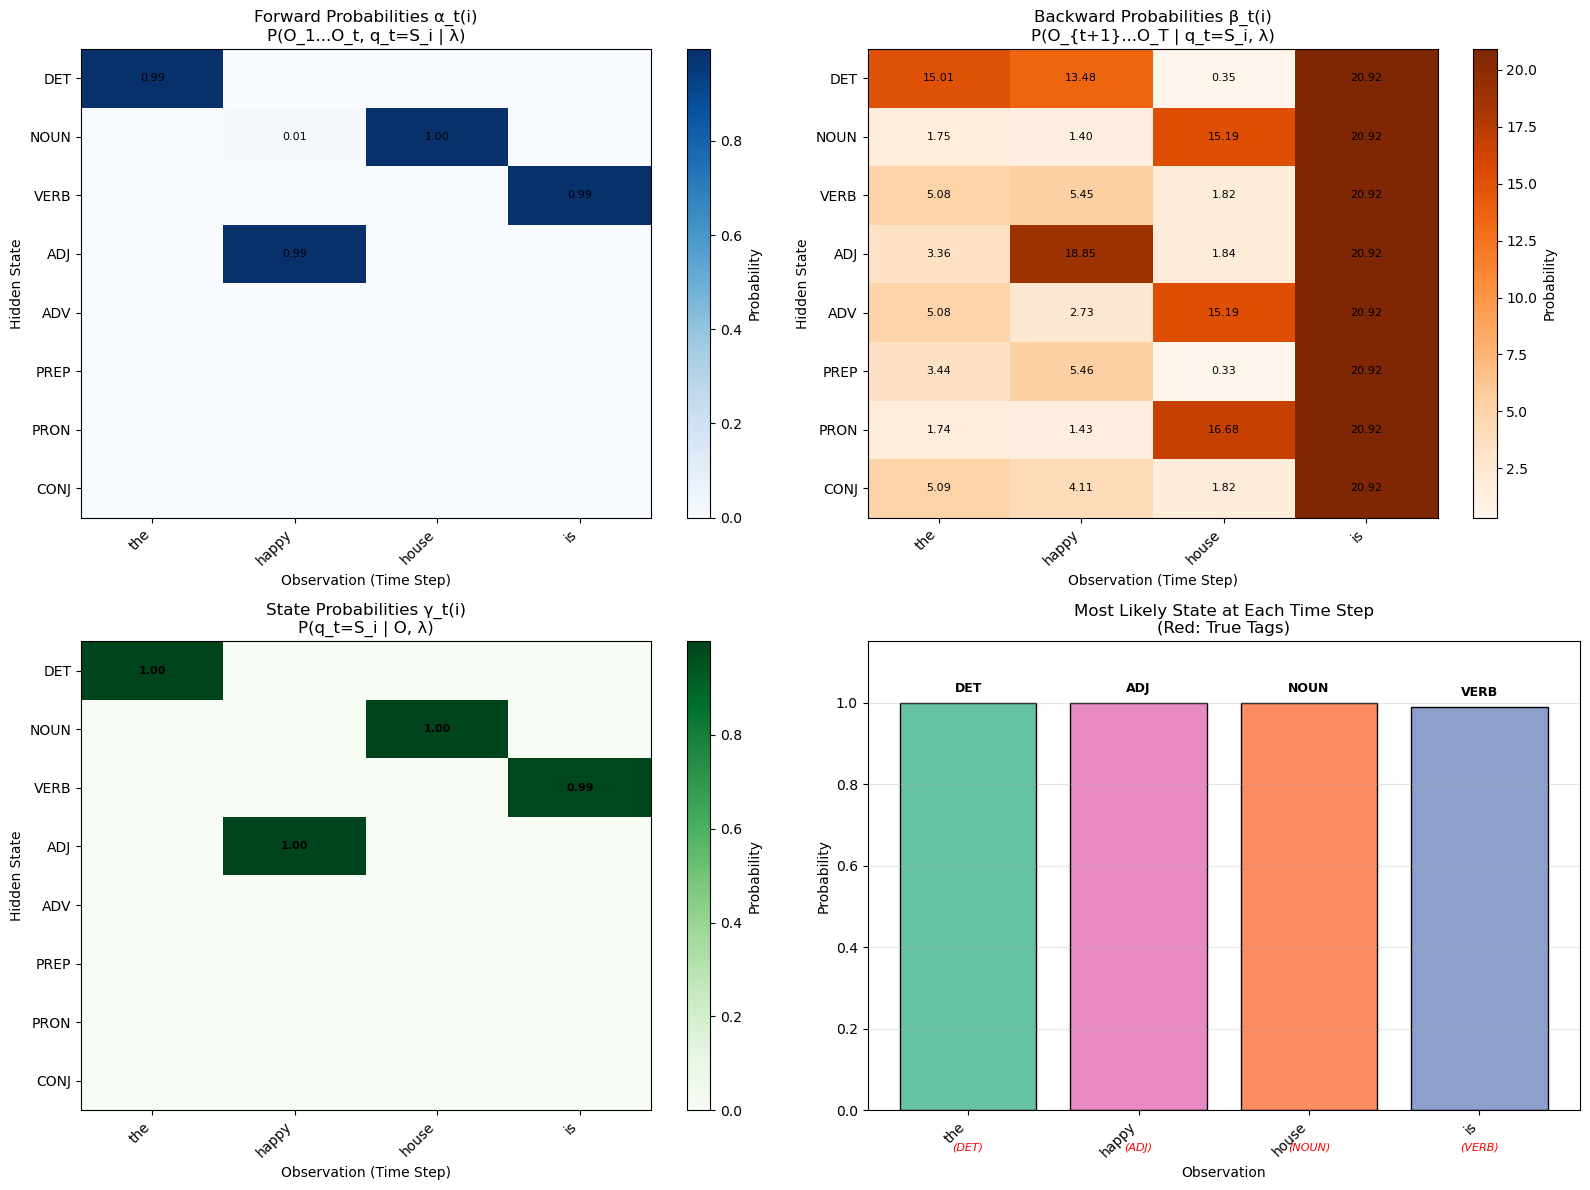

In [4]:
# =============================================================================
# 5. Main Execution
# =============================================================================

def main():
    print("=" * 80)
    print("HMM INFERENCE: FORWARD AND BACKWARD ALGORITHMS")
    print("=" * 80)
    
    # Set random seed
    random.seed(42)
    np.random.seed(42)
    
    # -------------------------------------------------------------------------
    # Step 1: Generate corpus and select test sentences
    # -------------------------------------------------------------------------
    print("\n1. GENERATING CORPUS...")
    corpus = generate_corpus(50)
    
    # Select a test sentence
    test_sentence = corpus[0]
    observations = [word for word, tag in test_sentence]
    true_tags = [tag for word, tag in test_sentence]
    
    print(f"\nTest Sentence: {' '.join(observations)}")
    print(f"True POS Tags: {' '.join(true_tags)}")
    
    # -------------------------------------------------------------------------
    # Step 2: Create HMM and set ground truth parameters
    # -------------------------------------------------------------------------
    print("\n2. CONSTRUCTING HMM WITH GROUND TRUTH PARAMETERS...")
    hmm = HiddenMarkovModel(POS_TAGS, VOCABULARY)
    hmm.set_ground_truth_parameters()
    
    # Display parameters
    print("\n   Initial Probabilities (π):")
    for i, tag in enumerate(POS_TAGS):
        print(f"      π({tag:4s}) = {hmm.pi[i]:.4f}")
    
    print("\n   Transition Matrix (A) - Sample:")
    print("      ", end="")
    for tag in POS_TAGS[:5]:
        print(f"{tag:>7s}", end="")
    print(" ...")
    for i in range(min(4, len(POS_TAGS))):
        print(f"   {POS_TAGS[i]:4s}", end="")
        for j in range(min(5, len(POS_TAGS))):
            print(f"{hmm.A[i,j]:7.3f}", end="")
        print(" ...")
    
    # -------------------------------------------------------------------------
    # Step 3: Run Forward Algorithm
    # -------------------------------------------------------------------------
    print("\n3. RUNNING FORWARD ALGORITHM...")
    alpha, scaling_factors, log_likelihood = hmm.forward(observations)
    
    print(f"\n   Observation sequence length: {len(observations)}")
    print(f"   Log-likelihood P(O|λ): {log_likelihood:.4f}")
    print(f"   Likelihood P(O|λ): {np.exp(log_likelihood):.6e}")
    
    print("\n   Forward probabilities α (scaled):")
    print("   " + "-" * 60)
    header = "   Time  Word      " + "  ".join(f"{tag:>6s}" for tag in POS_TAGS)
    print(header)
    print("   " + "-" * 60)
    for t, word in enumerate(observations):
        row = f"   {t:4d}  {word:8s} "
        row += "  ".join(f"{alpha[t,i]:6.3f}" for i in range(len(POS_TAGS)))
        print(row)
    
    # -------------------------------------------------------------------------
    # Step 4: Run Backward Algorithm
    # -------------------------------------------------------------------------
    print("\n4. RUNNING BACKWARD ALGORITHM...")
    beta = hmm.backward(observations, scaling_factors)
    
    print("\n   Backward probabilities β (scaled):")
    print("   " + "-" * 60)
    print(header)
    print("   " + "-" * 60)
    for t, word in enumerate(observations):
        row = f"   {t:4d}  {word:8s} "
        row += "  ".join(f"{beta[t,i]:6.3f}" for i in range(len(POS_TAGS)))
        print(row)
    
    # -------------------------------------------------------------------------
    # Step 5: Compute State Probabilities
    # -------------------------------------------------------------------------
    print("\n5. COMPUTING STATE PROBABILITIES γ_t(i)...")
    gamma = hmm.compute_gamma(alpha, beta)
    
    print("\n   State probabilities γ = P(q_t = i | O, λ):")
    print("   " + "-" * 60)
    print(header)
    print("   " + "-" * 60)
    for t, word in enumerate(observations):
        row = f"   {t:4d}  {word:8s} "
        row += "  ".join(f"{gamma[t,i]:6.3f}" for i in range(len(POS_TAGS)))
        max_idx = np.argmax(gamma[t])
        row += f"  → {POS_TAGS[max_idx]}"
        print(row)
    
    # -------------------------------------------------------------------------
    # Step 6: Run Viterbi for comparison
    # -------------------------------------------------------------------------
    print("\n6. RUNNING VITERBI ALGORITHM (Most Likely Path)...")
    best_path, best_prob, delta = hmm.viterbi(observations)
    
    print(f"\n   Viterbi best path: {' '.join(best_path)}")
    print(f"   True tags:         {' '.join(true_tags)}")
    print(f"   Best path probability: {best_prob:.6e}")
    
    # Calculate accuracy
    correct = sum(1 for pred, true in zip(best_path, true_tags) if pred == true)
    accuracy = correct / len(true_tags) * 100
    print(f"   Accuracy: {correct}/{len(true_tags)} = {accuracy:.1f}%")
    
    # -------------------------------------------------------------------------
    # Step 7: Print detailed algorithm steps
    # -------------------------------------------------------------------------
    print_algorithm_steps(observations, alpha, beta, gamma, hmm, log_likelihood)
    
    # -------------------------------------------------------------------------
    # Step 8: Visualizations
    # -------------------------------------------------------------------------
    print("\n7. GENERATING VISUALIZATIONS...")
    visualize_forward_backward(observations, alpha, beta, gamma, POS_TAGS, true_tags)
    visualize_trellis(observations, alpha, beta, POS_TAGS, best_path)
    
    # -------------------------------------------------------------------------
    # Test on additional sentences
    # -------------------------------------------------------------------------
    print("\n" + "=" * 80)
    print("TESTING ON ADDITIONAL SENTENCES")
    print("=" * 80)
    
    for idx in [1, 2, 3]:
        test_sent = corpus[idx]
        obs = [word for word, tag in test_sent]
        true = [tag for word, tag in test_sent]
        
        print(f"\nSentence {idx}: {' '.join(obs)}")
        print(f"True tags:   {' '.join(true)}")
        
        alpha_t, sf_t, ll_t = hmm.forward(obs)
        beta_t = hmm.backward(obs, sf_t)
        gamma_t = hmm.compute_gamma(alpha_t, beta_t)
        best_path_t, _, _ = hmm.viterbi(obs)
        
        predicted = [POS_TAGS[np.argmax(gamma_t[t])] for t in range(len(obs))]
        print(f"Predicted:   {' '.join(predicted)}")
        print(f"Viterbi:     {' '.join(best_path_t)}")
        
        correct = sum(1 for p, t in zip(best_path_t, true) if p == t)
        print(f"Accuracy:    {correct}/{len(true)} = {correct/len(true)*100:.1f}%")
    
    print("\n" + "=" * 80)
    print("COMPLETE!")
    print("=" * 80)
    
    return hmm, alpha, beta, gamma

if __name__ == "__main__":
    hmm, alpha, beta, gamma = main()